# Clase 4 · Movimiento browniano y modelo log-normal

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/prof-rodolfo-medina/modelizacion-derivados-carteras/blob/main/sesiones/semana-04/clase-04-movimiento-browniano-lognormal.ipynb)

**Semana 4 (23–27/11/2026) · Tema 5 · 90 min (incluye resolución de la Actividad 1)**

Objetivos:
1. Simular el proceso de Wiener y comprobar sus propiedades.
2. Obtener el movimiento browniano geométrico como solución de la EDE log-normal.
3. Verificar por simulación la media y la varianza teóricas.
4. Comparar la solución exacta con el esquema de Euler-Maruyama.

In [1]:
# Configuración: funciona en local (repositorio clonado) y en Google Colab
import sys, subprocess, pathlib
try:
    import mvdc
except ImportError:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "git+https://github.com/prof-rodolfo-medina/modelizacion-derivados-carteras.git"], check=True)
    else:
        for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
            if (base / "src" / "mvdc").exists():
                sys.path.insert(0, str(base / "src"))
                break
    import mvdc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3})
print("mvdc", mvdc.__version__)

mvdc 2026.11


## 1. Proceso de Wiener: 100 trayectorias (Figura 2 del tema)

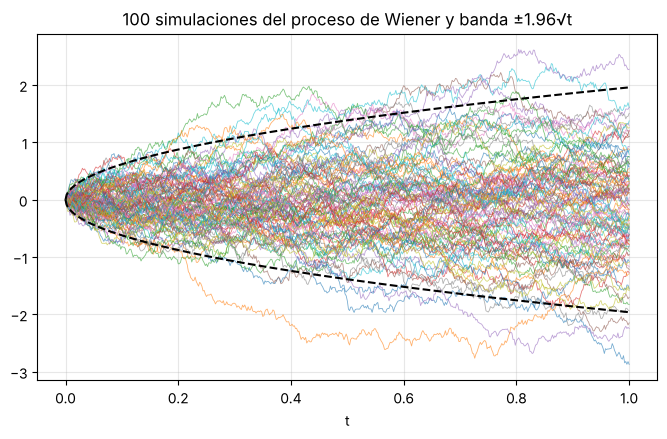

In [2]:
from mvdc import lognormal as ln

t, W = ln.wiener_paths(T=1, n_steps=500, n_paths=100, seed=7)
plt.plot(t, W.T, lw=0.6, alpha=0.6)
plt.plot(t, 1.96*np.sqrt(t), "k--", t, -1.96*np.sqrt(t), "k--", lw=1.5)
plt.title("100 simulaciones del proceso de Wiener y banda ±1.96√t"); plt.xlabel("t");

## 2. Comprobación empírica de las propiedades

- $W(t)\sim N(0,t)$
- $\operatorname{Cov}(W(t_1),W(t_2)) = \min\{t_1,t_2\}$

In [3]:
t, W = ln.wiener_paths(T=1, n_steps=100, n_paths=50_000, seed=1)
i1, i2 = 30, 80          # t1 = 0.3, t2 = 0.8
print(f"Var W(0.8): {W[:, i2].var():.4f}  (teórico 0.8)")
print(f"Cov(W(0.3), W(0.8)): {np.cov(W[:, i1], W[:, i2])[0, 1]:.4f}  (teórico 0.3)")

Var W(0.8): 0.8028  (teórico 0.8)
Cov(W(0.3), W(0.8)): 0.3010  (teórico 0.3)


## 3. Modelo log-normal

$$dS = \mu S\,dt + \sigma S\,dW \;\Rightarrow\; S(t) = S_0\,e^{(\mu-\sigma^2/2)t+\sigma W(t)}$$

$$E[S(t)] = S_0e^{\mu t},\qquad V[S(t)] = S_0^2e^{2\mu t}\left(e^{\sigma^2 t}-1\right)$$

Media  simulada 27.585  vs teórica 27.629
Desv.  simulada 8.437  vs teórica 8.479


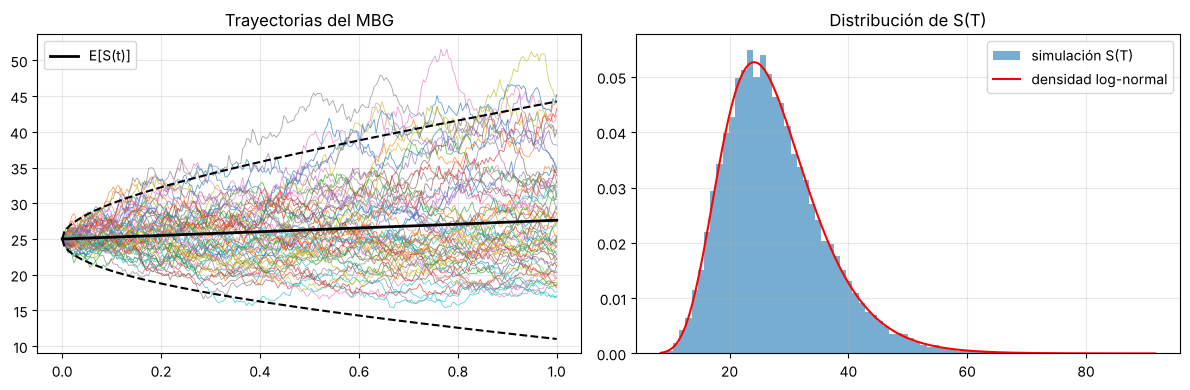

In [4]:
S0, mu, sigma, T = 25, 0.10, 0.30, 1.0
t, S = ln.gbm_paths(S0, mu, sigma, T, n_steps=252, n_paths=20_000, seed=3)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(t, S[:60].T, lw=0.6, alpha=0.7)
m, lo, hi = ln.confidence_band(S0, mu, sigma, t)
axs[0].plot(t, m, "k", lw=2, label="E[S(t)]"); axs[0].plot(t, lo, "k--", t, hi, "k--")
axs[0].set_title("Trayectorias del MBG"); axs[0].legend()

axs[1].hist(S[:, -1], bins=80, density=True, alpha=0.6, label="simulación S(T)")
from scipy.stats import lognorm
x = np.linspace(S[:, -1].min(), S[:, -1].max(), 300)
axs[1].plot(x, lognorm.pdf(x, s=sigma*np.sqrt(T), scale=S0*np.exp((mu-sigma**2/2)*T)), "r", label="densidad log-normal")
axs[1].legend(); axs[1].set_title("Distribución de S(T)"); plt.tight_layout()

print(f"Media  simulada {S[:, -1].mean():.3f}  vs teórica {ln.lognormal_mean(S0, mu, T):.3f}")
print(f"Desv.  simulada {S[:, -1].std():.3f}  vs teórica {ln.lognormal_std(S0, mu, sigma, T):.3f}")

## 4. Euler-Maruyama frente a la solución exacta (misma semilla ⇒ mismos incrementos)

In [5]:
for pasos in [5, 20, 100, 1000]:
    _, Sx = ln.gbm_paths(S0, mu, sigma, T, n_steps=pasos, n_paths=2000, seed=11)
    _, Se = ln.euler_maruyama(S0, mu, sigma, T, n_steps=pasos, n_paths=2000, seed=11)
    print(f"pasos={pasos:5d}   error fuerte medio |S_exacta − S_EM| en T: {np.abs(Sx[:, -1] - Se[:, -1]).mean():.4f}")

pasos=    5   error fuerte medio |S_exacta − S_EM| en T: 9.4537
pasos=   20   error fuerte medio |S_exacta − S_EM| en T: 9.2642
pasos=  100   error fuerte medio |S_exacta − S_EM| en T: 9.1001
pasos= 1000   error fuerte medio |S_exacta − S_EM| en T: 9.4761


## 5. Ejercicio en clase

Calcula por simulación $\operatorname{Cov}(S(t_1), S(t_2))$ y compárala con el resultado del
cuaderno de ejercicios del tema: $S_0^2e^{\mu(t_1+t_2)}\left(e^{\sigma^2\min\{t_1,t_2\}}-1\right)$.

In [6]:
# Tu código aquí

## 6. Resolución de la Actividad 1

La resolución comentada se comparte en la sesión **después** de la fecha de entrega
(23/11/2026). Puntos que revisaremos: desembolso inicial $C+P$, B/P a trozos,
puntos de equilibrio $E \pm (C+P)$, interpretación en términos de volatilidad y
calidad del informe según la rúbrica.